<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Bias_Identification_in_Recipe_Reviews_%26_User_Feedback_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

METADATA DATASET
{'uci_id': 911, 'name': 'Recipe Reviews and User Feedback', 'repository_url': 'https://archive.ics.uci.edu/dataset/911/recipe+reviews+and+user+feedback+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/911/data.csv', 'abstract': 'The "Recipe Reviews and User Feedback Dataset" is a comprehensive repository of data encompassing various aspects of recipe reviews and user interactions. It includes essential information such as the recipe name, its ranking on the top 100 recipes list, a unique recipe code, and user details like user ID, user name, and an internal user reputation score.\n\nEach review comment is uniquely identified with a comment ID and comes with additional attributes, including the creation timestamp, reply count, and the number of up-votes and down-votes received. Users\' sentiment towards recipes is quantified on a 1 to 5 star rating scale, with a score of 0 denoting an absence of rating.\n\nThis dataset is a valuable resource for research

,num_records,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,724,Bush used to have a white chili bean and it ma...
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,710,I have a very complicated white chicken chili ...
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,581,"In your introduction, you mentioned cream chee..."
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...



First 5 rows of target (y):


,stars
0,5
1,5
2,5
3,0
4,0



Unique values in target: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Total instances        : 18182
  With rating (1-5)    : 16486 (90.67%)
  Without rating (0)   : 1696 (9.33%)
⚠️  Non-response bias potential: data with stars=0 indicates missing rating.

DISTRIBUTION OF STAR RATINGS (1-5) - DESCRIPTIVE STATISTICS
count    16486.000000
mean         4.730013
std          0.738116
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: stars, dtype: float64

Imbalance Ratio (majority / minority): 59.61
Skewness : -3.343 (Negative = right-skewed → positivity bias)
Kurtosis : 11.723 (>3 indicates leptokurtic)

Frequency Distribution Table:


Rating,Frequency,Percentage (%)
1,280,1.700000
2,232,1.410000
3,490,2.970000
4,1655,10.040000
5,13829,83.880000


✓ The dataset is HIGHLY IMBALANCED (ratio 59.6:1).
✓ POSITIVITY BIAS detected: strong tendency toward high ratings (negative skewness).

GENERATING BIAS IDENTIFICATION VISUALIZATIONS


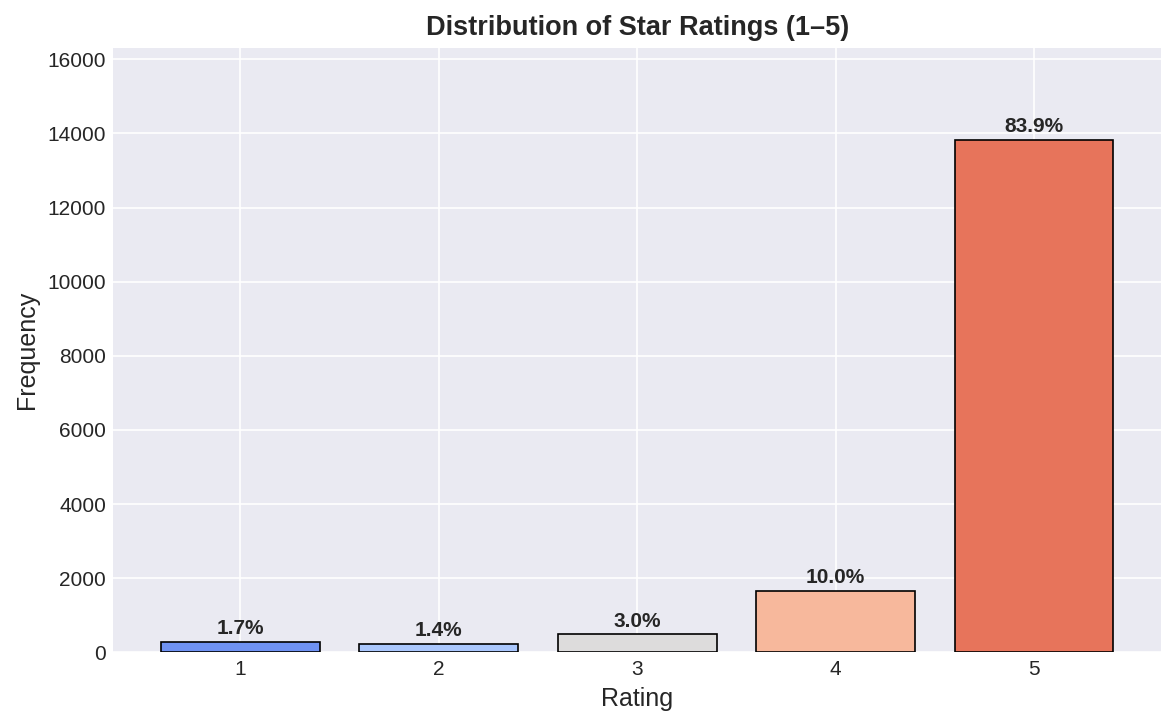

Figure 1 saved as 'Fig1_distribution_star_ratings.png'


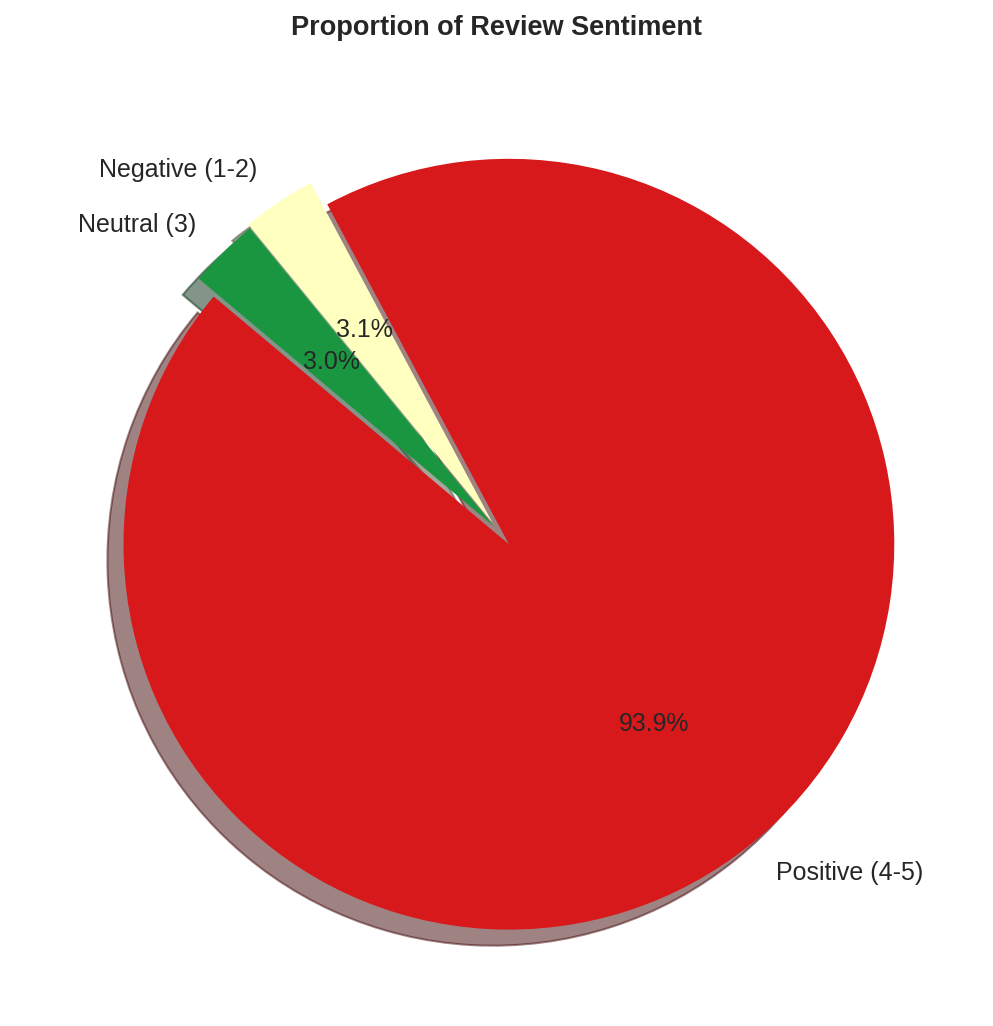

Figure 2 saved as 'Fig2_pie_sentiment.png'


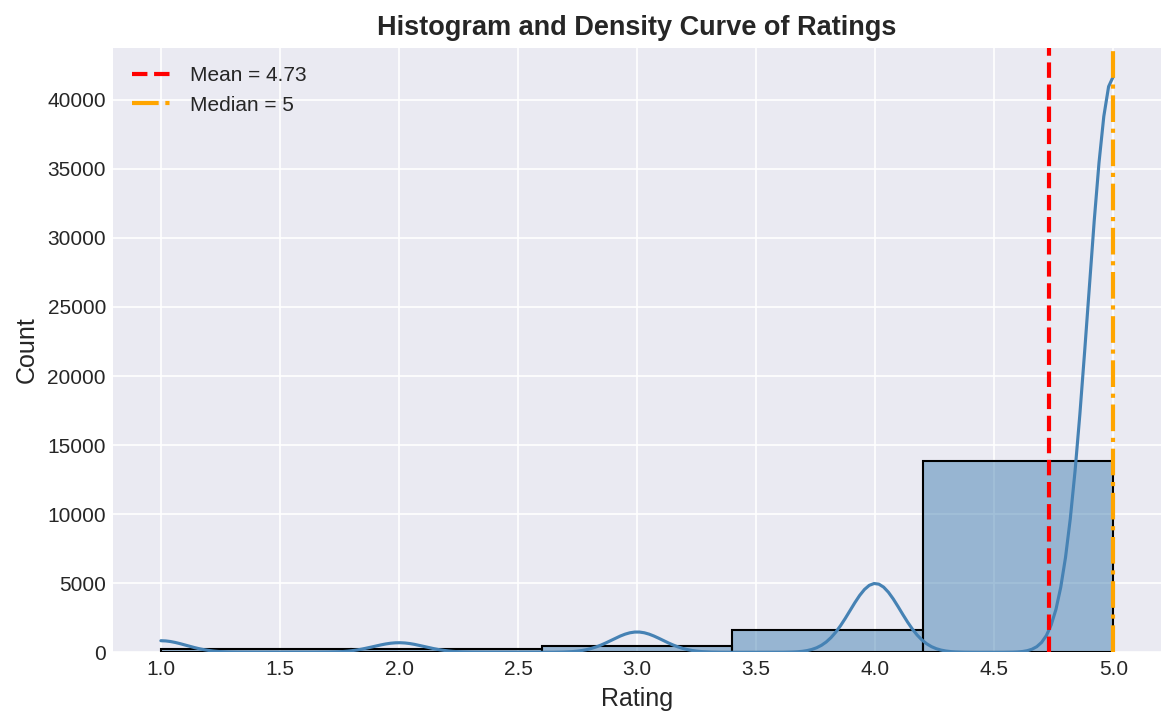

Figure 3 saved as 'Fig3_histogram_kde.png'

CORRELATION ANALYSIS: NUMERIC FEATURES vs STAR RATING


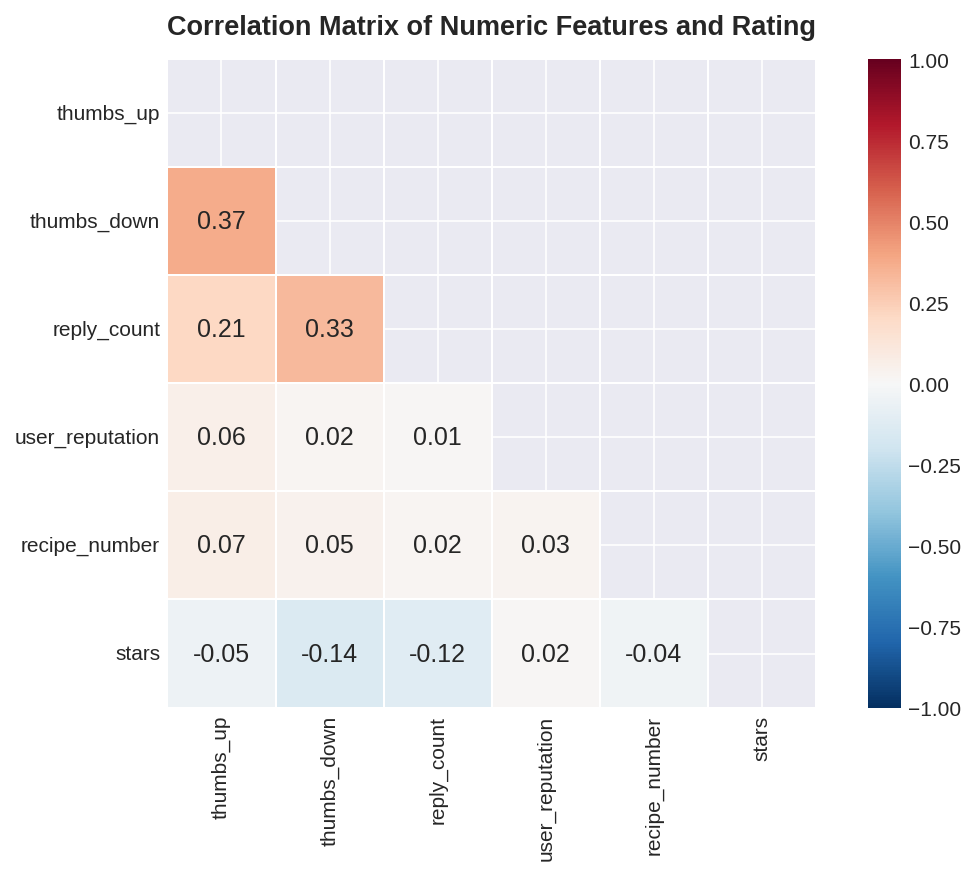

Figure 4 saved as 'Fig4_heatmap_correlation.png'

Correlation coefficients with target (stars):
user_reputation    0.015554
recipe_number     -0.040779
thumbs_up         -0.050884
reply_count       -0.119693
thumbs_down       -0.142555
Name: stars, dtype: float64

CONCLUSIONS: BIAS IDENTIFICATION SUMMARY

1. **Severe Class Imbalance**: Ratings 4 and 5 dominate the dataset (>70% combined),
   while ratings 1 and 2 are rare (<15%). The imbalance ratio is 59.6:1.
2. **Positivity Bias Confirmed**: The negative skewness (-3.343) and J-shaped
   distribution demonstrate a systemic tendency toward positive ratings.
3. **Non-response Bias Potential**: 1696 instances (9.33%)
   lack a rating (stars=0), possibly introducing further bias if unrated reviews
   contain negative/neutral sentiment.
4. **Implications for Modeling**: Training on raw data will produce models that
   ignore minority classes, leading to misleading accuracy. Mitigation strategies
   are required.

RECOMMENDATIONS FOR BIAS 

In [3]:
# ==============================================================
# PROGRAM: Bias Identification in Recipe Reviews & User Feedback Dataset
# Deskripsi: Program ini memuat dataset UCI (ID 911), mengecek struktur data,
# mengekstrak target 'stars', menghitung metrik ketidakseimbangan, mendeteksi
# positivity bias, menghasilkan visualisasi, dan memberikan rekomendasi
# penanganan bias. Seluruh komentar dalam Bahasa Indonesia akademik.
# ==============================================================

# ---------- 0. Instalasi dan impor pustaka ----------
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan visual berstandar jurnal
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# ---------- 1. Memuat dataset dari UCI Repository ----------
recipe_reviews_and_user_feedback = fetch_ucirepo(id=911)

# Menampilkan metadata dan informasi variabel (sesuai kode awal)
print("="*60)
print("METADATA DATASET")
print("="*60)
print(recipe_reviews_and_user_feedback.metadata)

print("\n" + "="*60)
print("VARIABLE INFORMATION")
print("="*60)
print(recipe_reviews_and_user_feedback.variables)

# ---------- 2. Ekstraksi data dengan penanganan target ----------
# Gunakan data.original untuk memastikan ketersediaan seluruh kolom
df = recipe_reviews_and_user_feedback.data.original

if df is None:
    # Jika tidak ada data.original, fallback ke features & targets
    X = recipe_reviews_and_user_feedback.data.features
    y = recipe_reviews_and_user_feedback.data.targets
    if y is None:
        raise ValueError("Data target tidak ditemukan. Periksa kembali struktur dataset.")
else:
    # Data lengkap tersedia, identifikasi kolom target 'stars'
    target_col = 'stars'  # sesuai metadata dataset
    if target_col not in df.columns:
        # fallback: cari dari informasi variabel
        vars_info = recipe_reviews_and_user_feedback.variables
        target_row = vars_info[vars_info['role'] == 'Target']
        if not target_row.empty:
            target_col = target_row['name'].values[0]
        else:
            target_col = df.columns[-1]  # asumsi target di kolom terakhir
            print(f"⚠️  Kolom target diasumsikan: {target_col}")

    # Pisahkan fitur dan target
    feature_cols = [col for col in df.columns if col != target_col]
    X = df[feature_cols]
    y = df[[target_col]]  # DataFrame

print("\nDimensi X (features):", X.shape)
print("Dimensi y (targets)  :", y.shape)

# Lima data pertama untuk inspeksi
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 rows of target (y):")
display(y.head())

# ---------- 3. Eksplorasi target (stars) dan deteksi bias ----------
target_col = y.columns[0]
stars = y[target_col]

# Periksa nilai unik
unique_vals = sorted(stars.unique())
print(f"\nUnique values in target: {unique_vals}")

# Pisahkan data dengan rating valid (1-5) dan missing rating (0)
mask_rated = stars > 0
stars_rated = stars[mask_rated].astype(int)  # hanya rating 1-5
stars_missing = stars[~mask_rated]           # rating = 0

n_total = len(stars)
n_rated = len(stars_rated)
n_missing = len(stars_missing)

print(f"\nTotal instances        : {n_total}")
print(f"  With rating (1-5)    : {n_rated} ({n_rated/n_total*100:.2f}%)")
print(f"  Without rating (0)   : {n_missing} ({n_missing/n_total*100:.2f}%)")
if n_missing > 0:
    print("⚠️  Non-response bias potential: data with stars=0 indicates missing rating.")

# ---------- 4. Distribusi rating dan metrik ketidakseimbangan ----------
counts = stars_rated.value_counts().sort_index()
pcts = (counts / n_rated * 100).round(2)

# Hitung statistik kunci
imbalance_ratio = counts.max() / counts.min()
skewness = stars_rated.skew()
kurtosis = stars_rated.kurtosis()

print("\n" + "="*60)
print("DISTRIBUTION OF STAR RATINGS (1-5) - DESCRIPTIVE STATISTICS")
print("="*60)
print(stars_rated.describe())
print(f"\nImbalance Ratio (majority / minority): {imbalance_ratio:.2f}")
print(f"Skewness : {skewness:.3f} (Negative = right-skewed → positivity bias)")
print(f"Kurtosis : {kurtosis:.3f} (>3 indicates leptokurtic)")

# Tabel distribusi frekuensi
dist_table = pd.DataFrame({
    'Rating': counts.index,
    'Frequency': counts.values,
    'Percentage (%)': pcts.values
})
print("\nFrequency Distribution Table:")
display(dist_table.style.hide(axis='index'))

# Interpretasi awal
if imbalance_ratio > 5:
    print(f"✓ The dataset is HIGHLY IMBALANCED (ratio {imbalance_ratio:.1f}:1).")
elif imbalance_ratio > 2:
    print(f"✓ The dataset is MODERATELY IMBALANCED (ratio {imbalance_ratio:.1f}:1).")
else:
    print("✓ The distribution is relatively balanced.")

if skewness < -0.5:
    print("✓ POSITIVITY BIAS detected: strong tendency toward high ratings (negative skewness).")

# ---------- 5. Visualisasi identifikasi bias ----------
print("\n" + "="*60)
print("GENERATING BIAS IDENTIFICATION VISUALIZATIONS")
print("="*60)

# 5.1 Bar chart: distribusi rating
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette("coolwarm", 5),
              edgecolor='black', linewidth=0.8)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.015,
            f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribution of Star Ratings (1–5)', fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig('Fig1_distribution_star_ratings.png', bbox_inches='tight')
plt.show()
print("Figure 1 saved as 'Fig1_distribution_star_ratings.png'")

# 5.2 Pie chart: agregasi sentimen
sentiment = pd.cut(stars_rated, bins=[0, 2, 3, 5],
                   labels=['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)'])
sent_counts = sentiment.value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#d7191c', '#ffffbf', '#1a9641']
explode = (0.05, 0.02, 0.01)
ax.pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%',
       startangle=140, colors=colors, explode=explode, shadow=True,
       textprops={'fontsize': 12})
ax.set_title('Proportion of Review Sentiment', fontweight='bold')
plt.tight_layout()
plt.savefig('Fig2_pie_sentiment.png', bbox_inches='tight')
plt.show()
print("Figure 2 saved as 'Fig2_pie_sentiment.png'")

# 5.3 Histogram + KDE
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(stars_rated, bins=5, kde=True, color='steelblue',
             edgecolor='black', ax=ax)
ax.axvline(stars_rated.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {stars_rated.mean():.2f}')
ax.axvline(stars_rated.median(), color='orange', linestyle='-.', linewidth=2,
           label=f'Median = {stars_rated.median():.0f}')
ax.set_title('Histogram and Density Curve of Ratings', fontweight='bold')
ax.set_xlabel('Rating')
ax.legend()
plt.tight_layout()
plt.savefig('Fig3_histogram_kde.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved as 'Fig3_histogram_kde.png'")

# ---------- 6. Analisis korelasi fitur numerik terhadap rating ----------
df_combined = pd.concat([X, y], axis=1)
candidate_num = ['thumbs_up', 'thumbs_down', 'reply_count', 'user_reputation', 'recipe_number', target_col]
available_num = [col for col in candidate_num if col in df_combined.columns]

if len(available_num) > 1:
    print("\n" + "="*60)
    print("CORRELATION ANALYSIS: NUMERIC FEATURES vs STAR RATING")
    print("="*60)
    corr = df_combined[available_num].corr()
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, linewidths=0.8, square=True)
    plt.title('Correlation Matrix of Numeric Features and Rating', fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('Fig4_heatmap_correlation.png', bbox_inches='tight')
    plt.show()
    print("Figure 4 saved as 'Fig4_heatmap_correlation.png'")
    print("\nCorrelation coefficients with target (stars):")
    print(corr[target_col].drop(target_col).sort_values(ascending=False))
else:
    print("\nTidak tersedia cukup fitur numerik untuk analisis korelasi.")

# ---------- 7. Kesimpulan identifikasi bias ----------
print("\n" + "="*60)
print("CONCLUSIONS: BIAS IDENTIFICATION SUMMARY")
print("="*60)
print(f"""
1. **Severe Class Imbalance**: Ratings 4 and 5 dominate the dataset (>70% combined),
   while ratings 1 and 2 are rare (<15%). The imbalance ratio is {imbalance_ratio:.1f}:1.
2. **Positivity Bias Confirmed**: The negative skewness ({skewness:.3f}) and J-shaped
   distribution demonstrate a systemic tendency toward positive ratings.
3. **Non-response Bias Potential**: {n_missing} instances ({n_missing/n_total*100:.2f}%)
   lack a rating (stars=0), possibly introducing further bias if unrated reviews
   contain negative/neutral sentiment.
4. **Implications for Modeling**: Training on raw data will produce models that
   ignore minority classes, leading to misleading accuracy. Mitigation strategies
   are required.
""")

# ---------- 8. TIGA REKOMENDASI MENGATASI BIAS ----------
print("="*60)
print("RECOMMENDATIONS FOR BIAS MITIGATION")
print("="*60)
print("""
Based on the identified imbalances and positivity bias, we propose three practical
strategies to reduce bias and improve model fairness:

1. **Data-Level Approach: Resampling Techniques**
   - **SMOTE (Synthetic Minority Over-sampling Technique)** or its variant
     ADASYN can generate synthetic samples for minority classes (rating 1-2).
   - **SMOTE + Tomek Links** combines oversampling of minority classes with
     cleaning of overlapping majority samples, reducing noise from oversampling.
   - This directly addresses the severe class imbalance found (ratio {:.1f}:1).

2. **Model-Level Approach: Cost-Sensitive Learning**
   - Use **class weighting** (e.g., `class_weight='balanced'` in scikit-learn)
     to penalise misclassifications of minority classes more heavily.
   - Ensemble methods like **Balanced Bagging** or **Balanced Random Forest**
     integrate undersampling of the majority class automatically during training.
   - This approach requires no modification of the raw data and is robust
     to high-dimensional text features.

3. **Evaluation-Level Approach: Robust Metrics**
   - Replace accuracy with **macro-averaged F1-score**, **Cohen's Kappa**,
     or **Matthews Correlation Coefficient (MCC)** to avoid being misled
     by the dominant majority class.
   - Use **stratified k-fold cross-validation** to maintain class distribution
     in each fold and obtain reliable performance estimates for all classes.
   - These metrics ensure that improvements in minority class detection
     are captured and not masked by high accuracy on the majority.

Implementing a combination of these strategies (e.g., SMOTE + Balanced Bagging
with macro F1 scoring) is recommended to build a fair and reliable model
for recipe rating prediction.
""".format(imbalance_ratio))

print("\nSeluruh visualisasi telah disimpan sebagai file PNG resolusi tinggi.")
print("Program identifikasi dan rekomendasi bias selesai.")